# SBV2 03 - Document Dataset Loading

This notebook turns the accepted Sandbox V2 inputs into one unified document manifest. It combines the SROIE/FUNSD acquisition manifest, the ready menu/mockup visual-source handoff from Notebook 02c, and the small CORD smoke sidecar.

The important distinction here is task scope: not every row is a menu metric row. Menus and synthetic menu concepts enter menu extraction; receipts and forms stay as OCR/key-value controls; small sidecars stay available for OCR/layout smoke tests.

## Contract

Inputs:

- `data/interim/sandbox_v2/manifests/sbv2_01_acquisition_manifest.csv`
- `data/interim/sandbox_v2/manifests/sbv2_02c_ready_visual_sources_manifest.csv`
- `data/raw/sandbox_v2/smoke_sources/smoke_manifest.jsonl`

Outputs:

- `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv`
- `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.parquet`
- source/task/ground-truth audit tables under `outputs/sandbox_v2/audit_tables/`
- visual QA figures under `outputs/figures/sandbox_v2/`

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "sandbox_v2").exists():
    candidates = [parent for parent in ROOT.parents if (parent / "sandbox_v2").exists()]
    if candidates:
        ROOT = candidates[0]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

CACHE_DIR = Path(os.environ.get("MENUFORGE_CACHE_HOME", ROOT / ".cache")).resolve()
for env_name, relative_path in {
    "XDG_CACHE_HOME": "",
    "MPLCONFIGDIR": "matplotlib",
    "JUPYTER_CONFIG_DIR": "jupyter_config",
    "JUPYTER_DATA_DIR": "jupyter_data",
    "JUPYTER_RUNTIME_DIR": "jupyter_runtime",
    "IPYTHONDIR": "ipython",
}.items():
    target = CACHE_DIR / relative_path if relative_path else CACHE_DIR
    target.mkdir(parents=True, exist_ok=True)
    os.environ.setdefault(env_name, str(target))

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
print(f"Project root: {ROOT}")

Project root: /home/endy/menuforge


In [2]:
from sandbox_v2.document_dataset_loading import write_outputs

summary = write_outputs()
print(json.dumps({
    "manifest_rows": summary["manifest_rows"],
    "ready_images": summary["ready_images"],
    "menu_extraction_rows": summary["menu_extraction_rows"],
    "ocr_baseline_rows": summary["ocr_baseline_rows"],
    "key_value_rows": summary["key_value_rows"],
    "layout_smoke_rows": summary["layout_smoke_rows"],
    "load_issue_rows": summary["load_issue_rows"],
    "manifest_csv": summary["manifest_csv"],
    "contact_sheet": summary["contact_sheet"],
}, indent=2))

{
  "manifest_rows": 848,
  "ready_images": 848,
  "menu_extraction_rows": 390,
  "ocr_baseline_rows": 848,
  "key_value_rows": 449,
  "layout_smoke_rows": 848,
  "load_issue_rows": 0,
  "manifest_csv": "data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv",
  "contact_sheet": "outputs/figures/sandbox_v2/sbv2_03_unified_document_contact_sheet.jpg"
}


In [3]:
manifest = pd.read_csv(ROOT / summary["manifest_csv"], low_memory=False)
source_mix = pd.read_csv(ROOT / summary["source_mix_csv"])
task_mix = pd.read_csv(ROOT / summary["task_mix_csv"])
ground_truth = pd.read_csv(ROOT / summary["ground_truth_coverage_csv"])
load_issues = pd.read_csv(ROOT / summary["load_issues_csv"])

display(Markdown("### Source Mix"))
display(source_mix)
display(Markdown("### Task Mix"))
display(task_mix)
display(Markdown("### Ground Truth Coverage"))
display(ground_truth)

### Source Mix

,source_id,dataset_family,evaluation_scope,rows,ready_images
0,cord,receipt,ocr_layout_sidecar,2,2
1,funsd,form,form_kv_ground_truth,149,149
2,nypl,menu,menu_extraction_candidate,30,30
3,nypl_expanded,menu,menu_extraction_candidate,120,120
4,sroie,receipt,receipt_kv_ground_truth,300,300
5,synthetic_menu_concepts,menu,menu_extraction_candidate,240,240
6,wikimedia_commons_english_menus,menu,ocr_layout_sidecar,1,1
7,wikimedia_english_menus,menu,ocr_layout_sidecar,6,6


### Task Mix

,task_family,evaluation_scope,rows,ready_images
0,form_kv_ocr,form_kv_ground_truth,149,149
1,menu_ocr_extraction,menu_extraction_candidate,390,390
2,menu_ocr_extraction,ocr_layout_sidecar,7,7
3,receipt_kv_ocr,receipt_kv_ground_truth,300,300
4,receipt_line_item_smoke,ocr_layout_sidecar,2,2


### Ground Truth Coverage

,source_id,task_family,rows,ground_truth_available,has_annotation_file,has_ground_truth_file,can_eval_ocr_words,can_eval_kv_entities,can_eval_menu_items,can_eval_prices
0,cord,receipt_line_item_smoke,2,0,0,0,0,0,0,0
1,funsd,form_kv_ocr,149,149,149,149,149,149,0,0
2,nypl,menu_ocr_extraction,30,11,0,0,0,0,0,0
3,nypl_expanded,menu_ocr_extraction,120,120,0,120,0,0,120,120
4,sroie,receipt_kv_ocr,300,300,300,300,300,300,0,0
5,synthetic_menu_concepts,menu_ocr_extraction,240,240,0,240,0,0,240,240
6,wikimedia_commons_english_menus,menu_ocr_extraction,1,0,0,0,0,0,0,0
7,wikimedia_english_menus,menu_ocr_extraction,6,0,0,0,0,0,0,0


In [4]:
preview_cols = [
    "unified_document_id",
    "source_id",
    "dataset_family",
    "task_family",
    "evaluation_scope",
    "include_in_menu_extraction",
    "include_in_ocr_baseline",
    "can_eval_menu_items",
    "has_local_image",
    "image_path",
]
display(manifest[preview_cols].head(15))

display(Markdown("### Menu Metric Candidates"))
display(
    manifest[manifest["include_in_menu_extraction"]]
    .groupby(["source_id", "can_eval_menu_items", "can_eval_prices"], dropna=False)
    .size()
    .reset_index(name="rows")
)

,unified_document_id,source_id,dataset_family,task_family,evaluation_scope,include_in_menu_extraction,include_in_ocr_baseline,can_eval_menu_items,has_local_image,image_path
0,sroie__sroie_00000,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_00000.jpg
1,sroie__sroie_1,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_1.jpg
2,sroie__sroie_2,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_2.jpg
3,sroie__sroie_3,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_3.jpg
4,sroie__sroie_4,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_4.jpg
5,sroie__sroie_5,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_5.jpg
6,sroie__sroie_6,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_6.jpg
7,sroie__sroie_7,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_7.jpg
8,sroie__sroie_8,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_8.jpg
9,sroie__sroie_9,sroie,receipt,receipt_kv_ocr,receipt_kv_ground_truth,False,True,False,True,data/raw/sandbox_v2/sroie/images/sroie_9.jpg


### Menu Metric Candidates

,source_id,can_eval_menu_items,can_eval_prices,rows
0,nypl,False,False,30
1,nypl_expanded,True,True,120
2,synthetic_menu_concepts,True,True,240


### Unified Document Contact Sheet

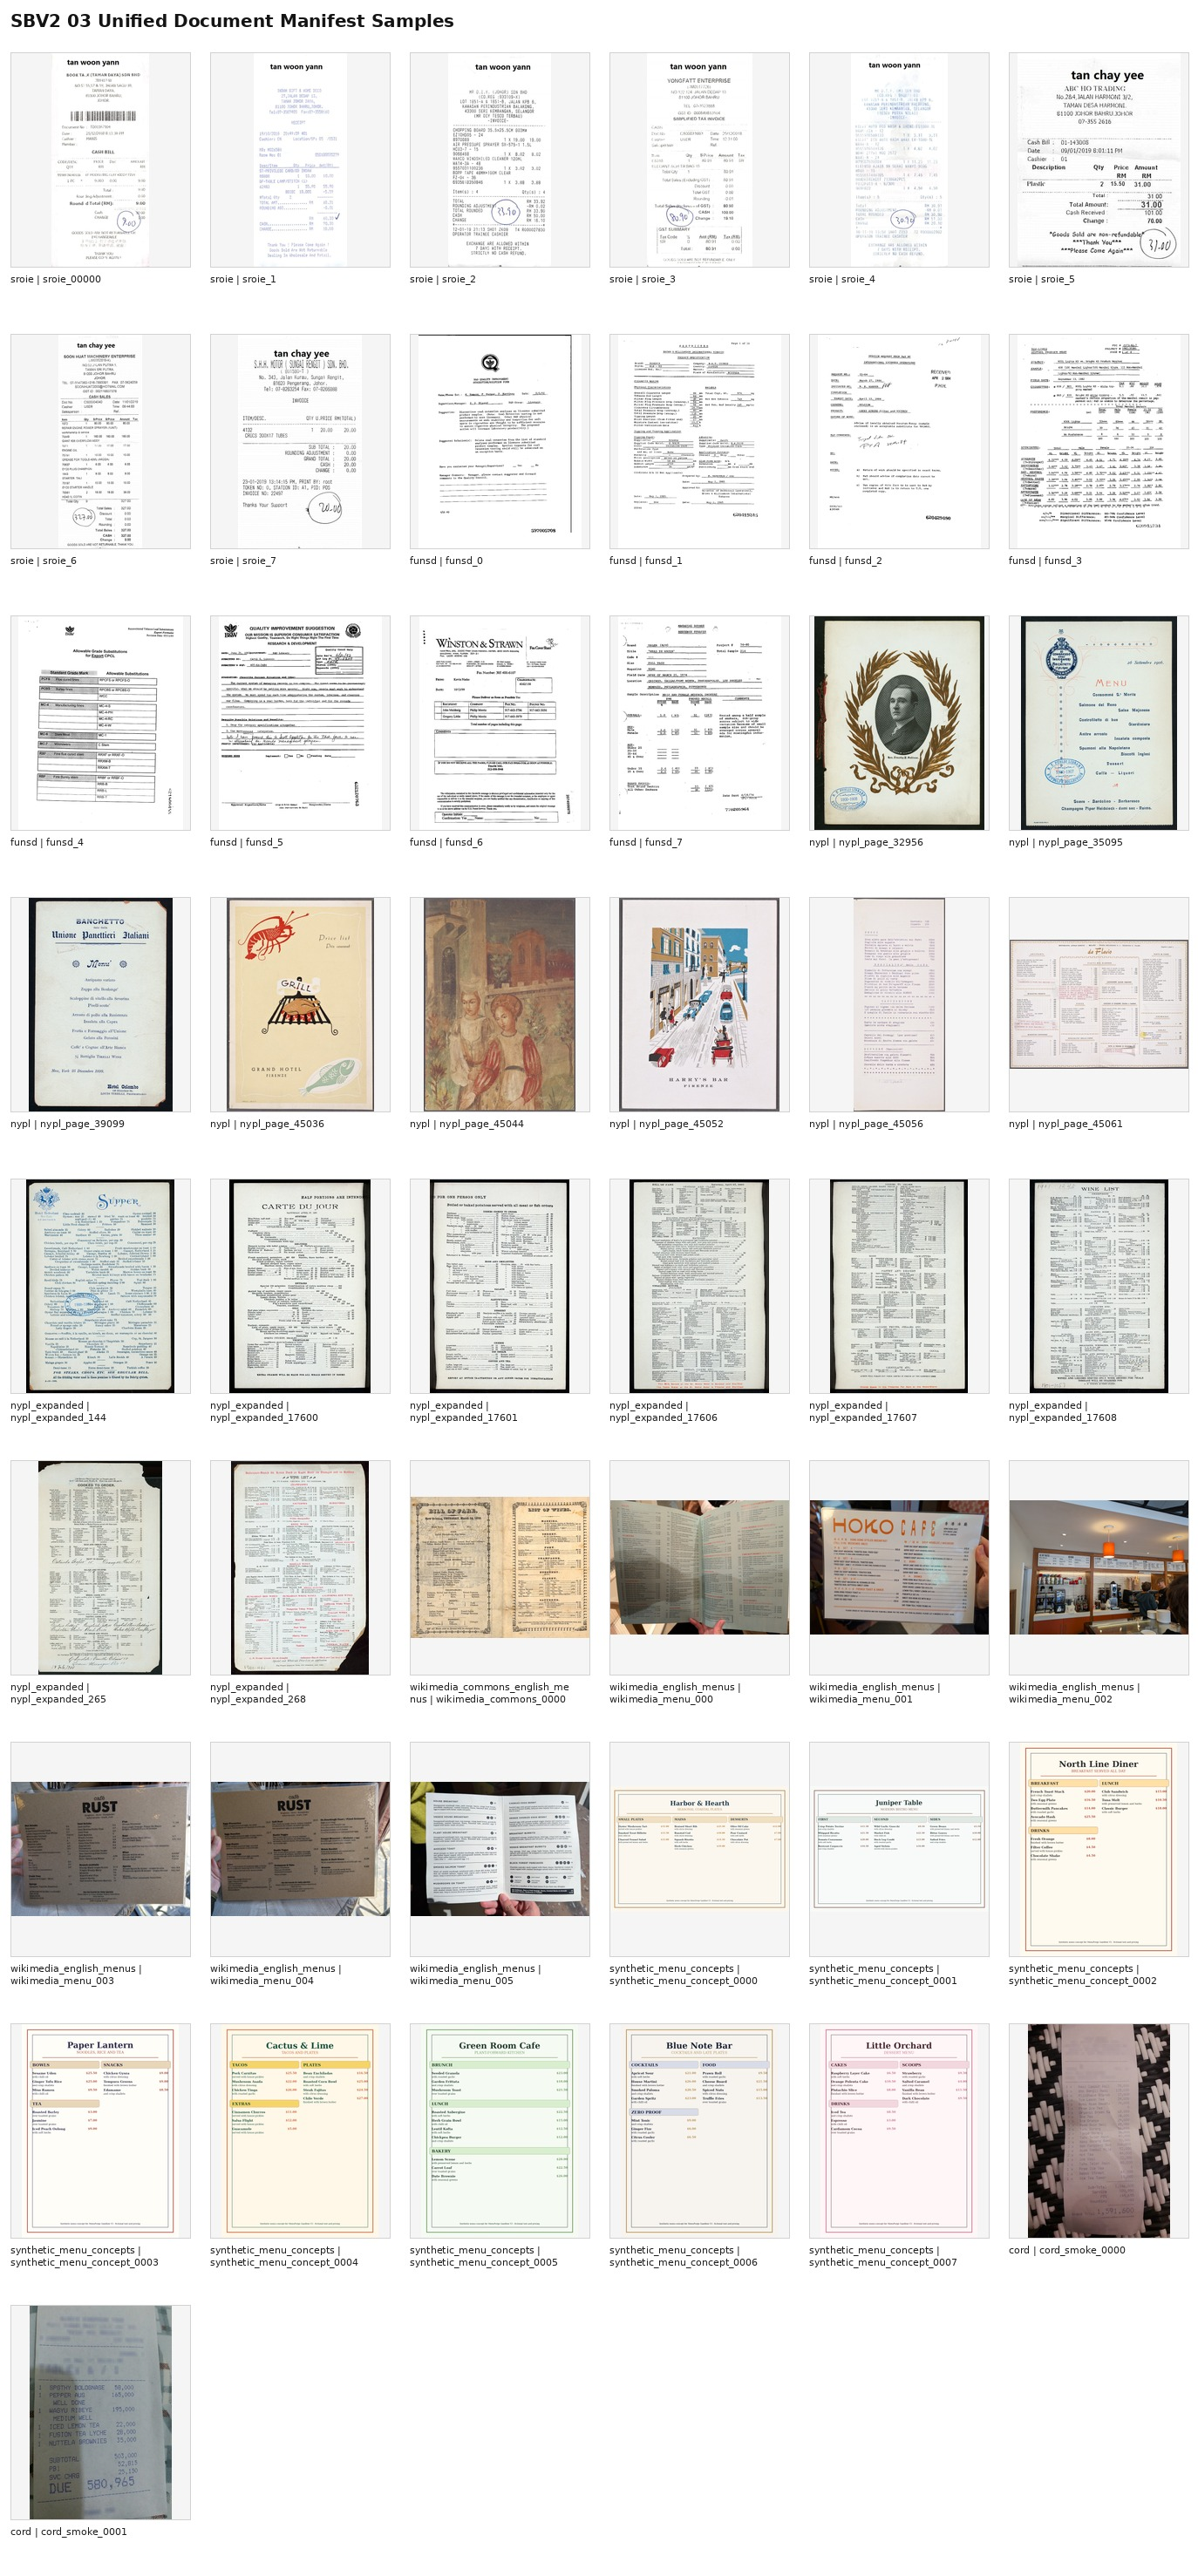

### Source Mix Chart

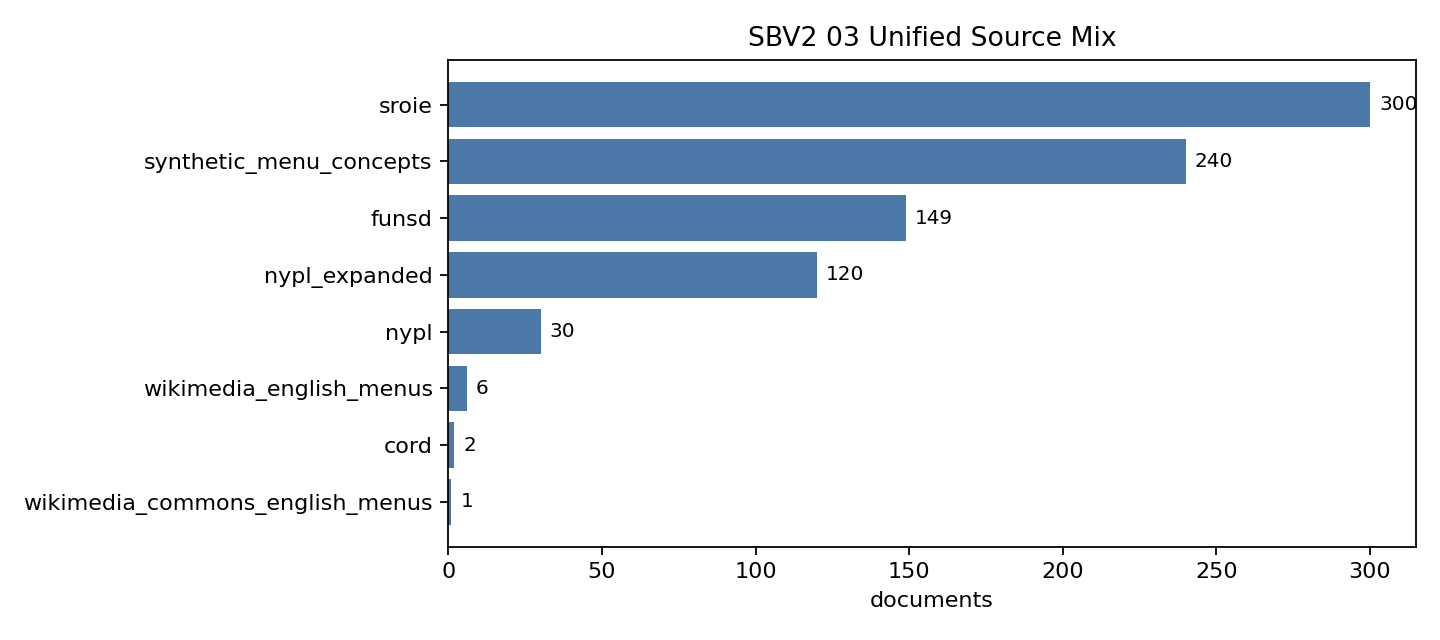

In [5]:
display(Markdown("### Unified Document Contact Sheet"))
display(Image(filename=str(ROOT / summary["contact_sheet"])))

if summary.get("source_mix_chart"):
    display(Markdown("### Source Mix Chart"))
    display(Image(filename=str(ROOT / summary["source_mix_chart"])))

In [6]:
if load_issues.empty:
    display(Markdown("### Load Issues\n\nNo missing images or duplicate unified document ids were found."))
else:
    display(Markdown("### Load Issues"))
    display(load_issues)

### Load Issues

No missing images or duplicate unified document ids were found.

## Handoff To Notebook 04

Notebook 04 should read `data/interim/sandbox_v2/manifests/sbv2_03_document_manifest.csv`.

Use `include_in_ocr_baseline == True` for the OCR pass. Use `include_in_menu_extraction == True` for menu extraction experiments. Use `can_eval_menu_items` and `can_eval_prices` to decide which rows can enter menu item/price metrics. Sidecar rows are still useful for qualitative OCR/layout checks, but they should not be scored as menu-schema truth.